SESSION 5

1.
Implement the Leaky ReLU activation function in Python as a function leaky_relu(x, alpha=0.01), and test it on an array of values ranging from -5 to 5.

In [ ]:
import numpy as np

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

x = np.arange(-5, 6)

print("Input:", x)
print("Leaky ReLU Output:", leaky_relu(x))

Input: [-5 -4 -3 -2 -1  0  1  2  3  4  5]
Leaky ReLU Output: [-0.05 -0.04 -0.03 -0.02 -0.01  0.    1.    2.    3.    4.    5.  ]


2.
Write a Python function parametric_relu(x, a) where 'a' is a learnable parameter (try a=0.2), and plot its output for x values from -5 to 5 using matplotlib.<br><br><em><strong>Hint:</strong> Compare the graph with standard ReLU and Leaky ReLU on the same plot for better understanding.</em>

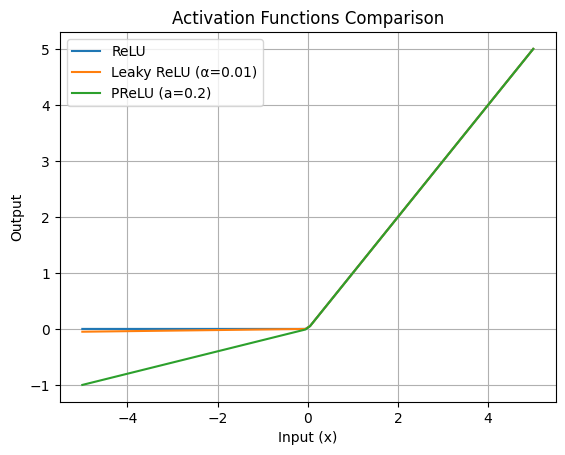

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def parametric_relu(x, a):
    return np.where(x > 0, x, a * x)

x = np.linspace(-5, 5, 100)

plt.plot(x, relu(x), label="ReLU")
plt.plot(x, leaky_relu(x), label="Leaky ReLU (α=0.01)")
plt.plot(x, parametric_relu(x, 0.2), label="PReLU (a=0.2)")

plt.xlabel("Input (x)")
plt.ylabel("Output")
plt.title("Activation Functions Comparison")
plt.legend()
plt.grid(True)
plt.show()

3.
Given a list of predicted scores for 4 classes: [2.0, 1.0, 0.1, 0.5], implement the softmax function in Python and print the resulting probabilities rounded to 3 decimal places.

In [ ]:
scores = [2.0, 1.0, 0.1, 0.5]

import numpy as np

def softmax(x):
    exp_values = np.exp(x)
    return exp_values / np.sum(exp_values)

scores = np.array([2.0, 1.0, 0.1, 0.5])

probabilities = softmax(scores)

print(np.round(probabilities, 3))

[0.575 0.211 0.086 0.128]


4.
Write a function hard_sigmoid(x) that implements the hard sigmoid activation (output between 0 and 1), and test it on inputs: -3, -1, 0, 1, 3.<br><br><em><strong>Hint:</strong> Use the formula: hard_sigmoid(x) = max(0, min(1, 0.2*x + 0.5)).</em>

In [ ]:
def hard_sigmoid(x):
    return max(0, min(1, 0.2 * x + 0.5))

inputs = [-3, -1, 0, 1, 3]

for i in inputs:
    print(f"x={i}, output={hard_sigmoid(i)}")

x=-3, output=0
x=-1, output=0.3
x=0, output=0.5
x=1, output=0.7
x=3, output=1


5.
Suppose you are building a multi-class image classifier for food items (like Zomato's food image feed). For each layer below, choose and justify the best activation function: (a) hidden dense layer, (b) output layer with 5 classes, (c) output layer with binary classification.<br><br><em><strong>Constraint:</strong> Write 1-2 lines of reasoning for each choice.</em>

5. Activation Functions for a Food Image Classifier
(a) Hidden Dense Layer

Activation Function: ReLU (Rectified Linear Unit)

Reason:
ReLU is fast and computationally efficient. It helps the network learn complex patterns in food images and reduces the vanishing gradient problem.

(b) Output Layer with 5 Classes

Activation Function: Softmax

Reason:
Softmax converts the output values into probabilities that sum to 1. It is ideal for multi-class classification where the image belongs to one of five food categories.

(c) Output Layer with Binary Classification

Activation Function: Sigmoid

Reason:
Sigmoid produces a probability between 0 and 1, making it suitable for binary classification tasks such as "Food" vs. "Not Food" or "Veg" vs. "Non-Veg".

SESSION 6


1.
Create a Python script using NumPy to perform a manual forward pass for a single-layer neural network: given an input vector X and a weight matrix W, compute the dot product and apply the sigmoid activation function to get the output.

In [ ]:
import numpy as np

# Sigmoid activation
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Input vector
X = np.array([1, 2, 3])

# Weight matrix
W = np.array([
    [0.2, 0.4],
    [0.5, 0.1],
    [0.3, 0.7]
])

# Forward pass
Z = np.dot(X, W)
output = sigmoid(Z)

print("Dot Product (Z):")
print(Z)

print("\nOutput after Sigmoid:")
print(output)

Dot Product (Z):
[2.1 2.7]

Output after Sigmoid:
[0.89090318 0.93702664]


2.
Modify your script to handle a two-layer neural network: take an input vector, compute the first hidden layer's activations using a weight matrix and ReLU activation, then compute the output layer's activations using a second weight matrix and sigmoid activation.

In [ ]:
#Hidden Layer → ReLU
#Output Layer → Sigmoid

import numpy as np

# Activation Functions
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Input
X = np.array([1, 2, 3])

# Input → Hidden Weights
W1 = np.array([
    [0.2, 0.4, 0.1],
    [0.5, 0.1, 0.3],
    [0.3, 0.7, 0.2]
])

# Hidden → Output Weights
W2 = np.array([
    [0.6],
    [0.2],
    [0.4]
])

# Hidden Layer
hidden_input = np.dot(X, W1)
hidden_output = relu(hidden_input)

# Output Layer
final_input = np.dot(hidden_output, W2)
final_output = sigmoid(final_input)

print("Hidden Layer Activations:")
print(hidden_output)

print("\nFinal Output:")
print(final_output)

Hidden Layer Activations:
[2.1 2.7 1.3]

Final Output:
[0.91051994]


3.
Visualize the activations of each layer in your two-layer network using matplotlib — plot the input, hidden, and output activations as bar charts to show how data transforms through the network.<br><br><em><strong>Hint:</strong> Use plt.bar() for each layer and display them in separate subplots.</em>

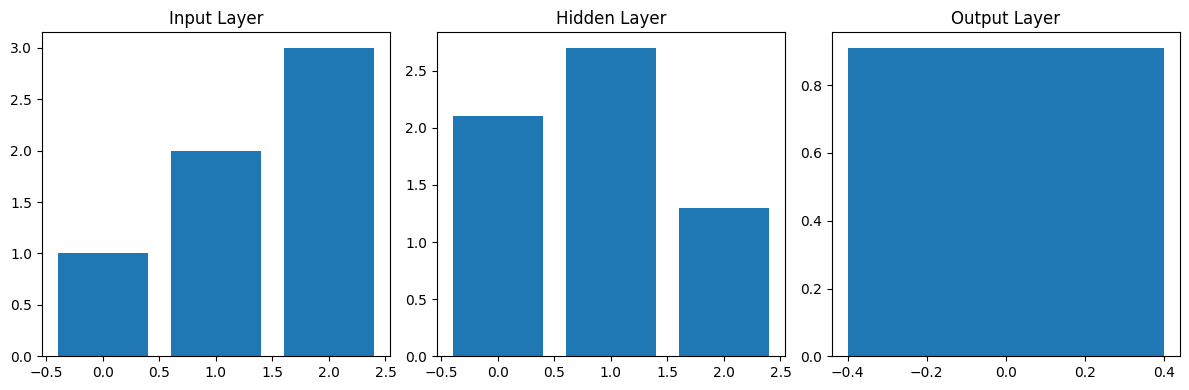

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Activations
input_layer = X
hidden_layer = hidden_output
output_layer = final_output

plt.figure(figsize=(12,4))

# Input Layer
plt.subplot(1,3,1)
plt.bar(range(len(input_layer)), input_layer)
plt.title("Input Layer")

# Hidden Layer
plt.subplot(1,3,2)
plt.bar(range(len(hidden_layer)), hidden_layer)
plt.title("Hidden Layer")

# Output Layer
plt.subplot(1,3,3)
plt.bar(range(len(output_layer)), output_layer)
plt.title("Output Layer")

plt.tight_layout()
plt.show()

4.
Given a set of random weights and a batch of three input vectors, perform a forward pass through a three-layer network (input, one hidden, output) and print the output activations for each input.<br><br><em><strong>Constraint:</strong> Use only NumPy for all matrix operations and activations.</em>

In [ ]:
import numpy as np

# Activation Functions
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Batch of 3 Inputs
X = np.array([
    [1, 2, 3],
    [2, 1, 0],
    [3, 2, 1]
])

# Random weights
np.random.seed(42)

W1 = np.random.rand(3, 4)  # Input → Hidden
W2 = np.random.rand(4, 2)  # Hidden → Output

# Hidden Layer
hidden_input = np.dot(X, W1)
hidden_output = relu(hidden_input)

# Output Layer
output_input = np.dot(hidden_output, W2)
output_output = sigmoid(output_input)

print("Output Activations:")
print(output_output)

Output Activations:
[[0.99467016 0.9590513 ]
 [0.92286514 0.87752459]
 [0.99364582 0.97532069]]


SESSION 7

1.
Write a Python function calculate_mse(predictions, targets) that takes two lists of numbers and returns the Mean Squared Error between them using the MSE formula.

In [ ]:
def calculate_mse(predictions, targets):
    n = len(predictions)
    mse = sum((p - t) ** 2 for p, t in zip(predictions, targets)) / n
    return mse

# Example
predictions = [2, 4, 6]
targets = [3, 5, 7]

print("MSE:", calculate_mse(predictions, targets))

MSE: 1.0


2.
Given two arrays: actual_ratings = [4, 3, 5, 2, 1] and predicted_ratings = [5, 2, 4, 2, 1], calculate the Mean Absolute Error (MAE) using Python and print the result.

In [ ]:
actual_ratings = [4, 3, 5, 2, 1]
predicted_ratings = [5, 2, 4, 2, 1]

mae = sum(abs(a - p) for a, p in zip(actual_ratings, predicted_ratings)) / len(actual_ratings)

print("MAE:", mae)

MAE: 0.6


3.
Implement a function binary_cross_entropy(y_true, y_pred) in Python that computes the binary cross-entropy loss for a batch of predictions and true labels (both as lists of 0s and 1s), then test it with y_true = [1, 0, 1] and y_pred = [0.9, 0.2, 0.7].

In [ ]:
import math

def binary_cross_entropy(y_true, y_pred):
    n = len(y_true)
    loss = 0

    for yt, yp in zip(y_true, y_pred):
        loss += yt * math.log(yp) + (1 - yt) * math.log(1 - yp)

    return -loss / n

# Test Data
y_true = [1, 0, 1]
y_pred = [0.9, 0.2, 0.7]

print("Binary Cross-Entropy Loss:",
      round(binary_cross_entropy(y_true, y_pred), 4))

Binary Cross-Entropy Loss: 0.2284


4.
Simulate a basic Categorical Cross-Entropy calculation: given y_true = [0, 0, 1] and y_pred = [0.2, 0.3, 0.5], write Python code to compute the categorical cross-entropy loss for this single data point.

In [ ]:
import math

y_true = [0, 0, 1]
y_pred = [0.2, 0.3, 0.5]

cce = -sum(t * math.log(p)
           for t, p in zip(y_true, y_pred))

print("Categorical Cross-Entropy Loss:",
      round(cce, 4))

Categorical Cross-Entropy Loss: 0.6931


5.
Pick any app you use daily (like Zomato, Spotify, or Instagram) and describe a real-world scenario where choosing the right loss function (MSE, MAE, Binary Cross-Entropy, or Categorical Cross-Entropy) would be important. Explain which loss function you would use and why.

Real-World Scenario: Spotify Music Recommendation
Scenario

Spotify recommends songs based on a user's listening history. The system predicts whether a user will like a song or not.

Loss Function Choice

Binary Cross-Entropy (BCE)

Reason

The prediction has two possible outcomes:

User likes the song (1)
User does not like the song (0)

Binary Cross-Entropy is ideal because it measures how well the predicted probabilities match the actual user preferences and helps improve recommendation accuracy.

SESSION 8

1.
Write a Python function compute_gradient(f, x) that takes a simple function f (like f(x) = x**2) and a value x, and returns the numerical gradient at x using the central difference method.<br><br><em><strong>Hint:</strong> Use (f(x+h) - f(x-h)) / (2*h) with a small h (e.g., 1e-5).</em>

In [ ]:
def compute_gradient(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

# Example function
def f(x):
    return x**2

x = 3

gradient = compute_gradient(f, x)

print("Gradient at x =", x, "is", gradient)

Gradient at x = 3 is 6.000000000039306


2.
Given the function f(x, y) = x**2 + y**2, calculate the partial derivatives with respect to x and y at the point (x=3, y=4) using Python.

In [ ]:
def partial_x(x, y):
    return 2 * x

def partial_y(x, y):
    return 2 * y

x = 3
y = 4

print("df/dx =", partial_x(x, y))
print("df/dy =", partial_y(x, y))

df/dx = 6
df/dy = 8


3.
Simulate one step of gradient descent for a function f(w) = (w-5)**2 starting from w=0, with a learning rate of 0.1. Print the updated value of w after the step.

In [ ]:
w = 0
learning_rate = 0.1

gradient = 2 * (w - 5)

w_new = w - learning_rate * gradient

print("Updated w =", w_new)

Updated w = 1.0


4.
Create a Python script that demonstrates how different learning rates (0.01, 0.1, 0.5) affect the convergence of gradient descent for f(x) = (x-3)**2. Plot the value of x over 20 iterations for each learning rate using matplotlib.<br><br><em><strong>Hint:</strong> Use a loop to update x for each learning rate and plot all three on the same graph.</em>

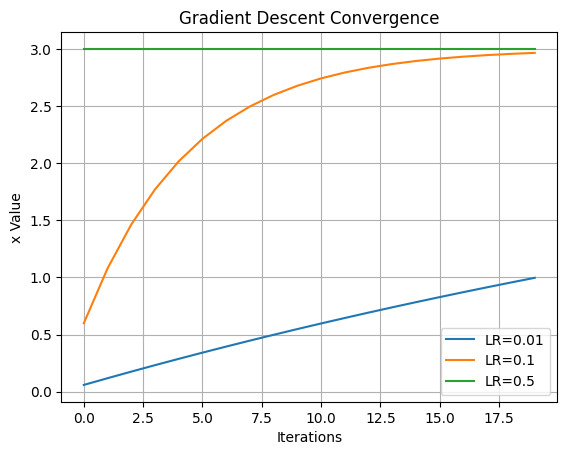

In [ ]:
import matplotlib.pyplot as plt

learning_rates = [0.01, 0.1, 0.5]
iterations = 20

for lr in learning_rates:

    x = 0
    values = []

    for i in range(iterations):

        gradient = 2 * (x - 3)

        x = x - lr * gradient

        values.append(x)

    plt.plot(range(iterations),
             values,
             label=f"LR={lr}")

plt.xlabel("Iterations")
plt.ylabel("x Value")
plt.title("Gradient Descent Convergence")
plt.legend()
plt.grid(True)
plt.show()

5.
Write a short Python function that generates and plots a graph of f(x) = x**4 - 3x**3 + 2 for x in range(-2, 4), and visually identify one local minimum and the global minimum on the plot.

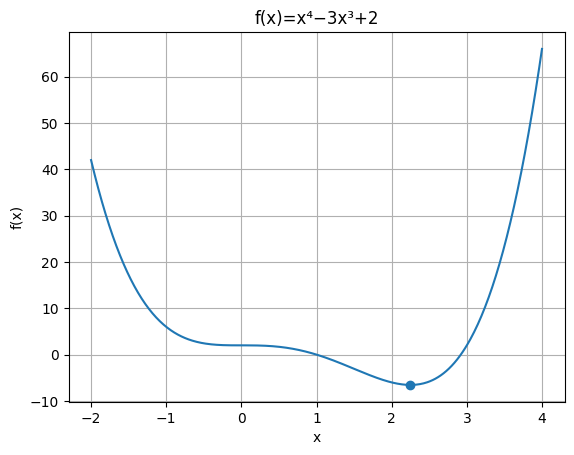

Approximate Global Minimum:
x = 2.25
f(x) = -6.54296875


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**4 - 3*x**3 + 2

x = np.linspace(-2, 4, 500)

y = f(x)

plt.plot(x, y)

# Global minimum near x = 2.25
xmin = 2.25
ymin = f(xmin)

plt.scatter(xmin, ymin)

plt.title("f(x)=x⁴−3x³+2")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)

plt.show()

print("Approximate Global Minimum:")
print("x =", xmin)
print("f(x) =", ymin)

session 17

1.Train a simple neural network to classify whether a review is positive or negative using a small dataset (you can use any dataset of your choice), then save the trained model to a .h5 file using model.save('sentiment_model.h5').

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Sample Dataset
reviews = [
    "This movie is amazing",
    "I love this product",
    "Excellent service",
    "Very happy with the purchase",
    "Fantastic experience",
    "This movie is terrible",
    "Worst product ever",
    "I hate this",
    "Very disappointing",
    "Bad experience"
]

labels = [1,1,1,1,1,0,0,0,0,0]  # 1=Positive, 0=Negative

# Tokenization
tokenizer = Tokenizer(num_words=1000)
tokenizer.fit_on_texts(reviews)

sequences = tokenizer.texts_to_sequences(reviews)
X = pad_sequences(sequences, maxlen=5)

y = np.array(labels)

# Build Model
model = Sequential([
    Dense(16, activation='relu', input_shape=(5,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
model.fit(X, y, epochs=20, validation_split=0.2)

# Save Model
model.save('sentiment_model.h5')

print("Model saved as sentiment_model.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3750 - loss: 1.1183 - val_accuracy: 1.0000 - val_loss: 0.0430
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3750 - loss: 1.0635 - val_accuracy: 1.0000 - val_loss: 0.0476
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3750 - loss: 1.0106 - val_accuracy: 1.0000 - val_loss: 0.0528
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3750 - loss: 0.9599 - val_accuracy: 1.0000 - val_loss: 0.0584
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.3750 - loss: 0.9116 - val_accuracy: 1.0000 - val_loss: 0.0649
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.3750 - loss: 0.8656 - val_accuracy: 1.0000 - val_loss: 0.0720
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5000 - loss: 0.8222 - val_accuracy: 1.0000 - val_loss: 0.0799
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5000 - loss: 0.7815 - val_accuracy: 1.0000 - val_loss: 0.0884
E

Model saved as sentiment_model.h5


2.Write code to load the 'sentiment_model.h5' file you saved and use it to predict the sentiment of three new sample reviews.

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load model
loaded_model = load_model('sentiment_model.h5')

# New Reviews
new_reviews = [
    "I really enjoyed this movie",
    "Worst service ever",
    "The product is good"
]

# Convert to sequences
new_seq = tokenizer.texts_to_sequences(new_reviews)
new_pad = pad_sequences(new_seq, maxlen=5)

# Predictions
predictions = loaded_model.predict(new_pad)

for review, pred in zip(new_reviews, predictions):
    sentiment = "Positive" if pred > 0.5 else "Negative"
    print(f"Review: {review}")
    print(f"Sentiment: {sentiment}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Review: I really enjoyed this movie
Sentiment: Positive

Review: Worst service ever
Sentiment: Negative

Review: The product is good
Sentiment: Positive



3.Implement model checkpointing during training so that the model's weights are saved every time the validation accuracy improves.<br><br><em><strong>Hint:</strong> Use the ModelCheckpoint callback in Keras with save_best_only=True.</em>

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

model.fit(
    X,
    y,
    epochs=20,
    validation_split=0.2,
    callbacks=[checkpoint]
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.2392
Epoch 1: val_accuracy improved from None to 0.50000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 1.0000 - loss: 0.2392 - val_accuracy: 0.5000 - val_loss: 0.5530
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.2354
Epoch 2: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 1.0000 - loss: 0.2354 - val_accuracy: 0.5000 - val_loss: 0.5653
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.2317
Epoch 3: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 1.0000 - loss: 0.2317 - val_accuracy: 0.5000 - val_loss: 0.5779
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.2281
Epoch 4: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 1.0000 - loss: 0.2281 - val_accuracy: 0.5000 - val_loss: 0.5907
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.2246
Epoch 5: 

4.Export your trained model in a format suitable for deployment (such as TensorFlow SavedModel format), and explain in one line how this format helps with deploying the model to a web or mobile app

In [ ]:
model.export("saved_sentiment_model")

Saved artifact at 'saved_sentiment_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140398049553744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140398049554896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140398049553552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140398049551632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140398049555472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140398049552400: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
model_json = model.to_json()

with open("model_architecture.json", "w") as json_file:
    json_file.write(model_json)

print("Architecture saved")

model.save_weights("model_weights.weights.h5")

print("Weights saved")

from tensorflow.keras.models import model_from_json

# Load Architecture
with open("model_architecture.json", "r") as json_file:
    loaded_json = json_file.read()

loaded_model = model_from_json(loaded_json)

# Load Weights
loaded_model.load_weights("model_weights.weights.h5")

# Compile Model
loaded_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model loaded successfully")

Architecture saved
Weights saved
Model loaded successfully


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
original_pred = model.predict(new_pad)
loaded_pred = loaded_model.predict(new_pad)

print("Original Predictions:")
print(original_pred)

print("\nLoaded Model Predictions:")
print(loaded_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Original Predictions:
[[0.5663857]
 [0.4930617]
 [0.7633954]]

Loaded Model Predictions:
[[0.5663857]
 [0.4930617]
 [0.7633954]]
